In [1]:
import sys
print(sys.executable)

C:\Users\user-1\.conda\envs\tf_env\python.exe


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training: Standard CNN


C:\Users\user-1\.conda\envs\tf_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\user-1\.conda\envs\tf_env\lib\site-packages\keras\src\layers\convolutional\base_separable_conv.py:104: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 34s 35ms/step - accuracy: 0.6492 - loss: 0.9461 - val_accuracy: 0.7654 - val_loss: 0.6620
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 33s 35ms/step - accuracy: 0.7743 - loss: 0.6247 - val_accuracy: 0.7946 - val_loss: 0.5815
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 34s 36ms/step - accuracy: 0.7986 - loss: 0.5591 - val_accuracy: 0.7956 - val_loss: 0.5725
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 37s 40ms/step - accuracy: 0.8175 - loss: 0.5077 - val_accuracy: 0.8044 - val_loss: 0.5293
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 33s 35ms/step - accuracy: 0.8311 - loss: 0.4739 - val_accuracy: 0.8243 - val_loss: 0.4810
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 33s 35ms/step - accuracy: 0.8423 - loss: 0.4427 - val_accuracy: 0.8449 - val_loss: 0.4348
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 35s 37ms/step - accuracy: 0.8507 - loss: 0.4142 - val_accuracy: 0.8316 - val_loss: 0.4563
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 33s 35ms/step - accuracy: 0.8602 - loss: 0.3901 - 

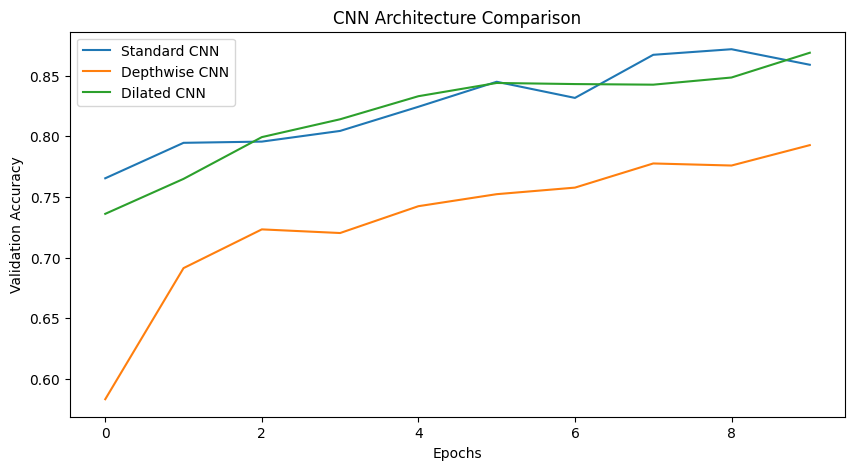

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Load dataset (NO download issues)
from tensorflow.keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize + reshape (grayscale → add channel)
x_train = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test = x_test.reshape(-1, 28, 28, 1) / 255.0

# 1. Standard CNN
def standard_cnn():
    return models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

# 2. Depthwise Separable CNN
def depthwise_cnn():
    return models.Sequential([
        layers.SeparableConv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
        layers.MaxPooling2D(2,2),
        layers.SeparableConv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.SeparableConv2D(128, (3,3), activation='relu', padding='same'),
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

# 3. Dilated CNN
def dilated_cnn():
    return models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', dilation_rate=2, input_shape=(28,28,1)),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (3,3), activation='relu', padding='same', dilation_rate=2),
        layers.MaxPooling2D(2,2),
        layers.SeparableConv2D(128, (3,3), activation='relu', padding='same'),
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

# Training function
def train(model):
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model.fit(x_train, y_train,
                     epochs=10,
                     batch_size=64,
                     validation_data=(x_test, y_test),
                     verbose=1)

# Train all models
models_dict = {
    "Standard CNN": standard_cnn(),
    "Depthwise CNN": depthwise_cnn(),
    "Dilated CNN": dilated_cnn()
}

histories = {}

for name, model in models_dict.items():
    print("\nTraining:", name)
    histories[name] = train(model)

# Plot comparison
plt.figure(figsize=(10,5))
for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name)

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("CNN Architecture Comparison")
plt.legend()
plt.show()